# SAC vs REINFORCE on Pendulum-v1 — Experiment Notebook

**Course:** Artificial Intelligence — Project 3
**Topic:** Reinforcement Learning on Pendulum-v1
**Algorithms:** Soft Actor-Critic (SAC) and REINFORCE

## References
- Haarnoja et al. (2018). *Soft Actor-Critic*. https://arxiv.org/abs/1801.01290
- Haarnoja et al. (2018). *SAC with auto-tuning*. https://arxiv.org/abs/1812.05905
- Williams (1992). *REINFORCE*. Machine Learning.
- SAC base code: https://github.com/XinJingHao/SAC-Continuous-Pytorch

## Experiments Overview
| # | Experiment | Variable | Values |
|---|-----------|----------|--------|
| 1 | Algorithm Comparison | algorithm | REINFORCE, SAC |
| 2 | Discount Factor | γ | 0.90, 0.95, 0.99 |
| 3 | Entropy Regularization | adaptive_alpha | False, True |
| 4 | Batch Size | batch_size | 64, 128, 256 |

## 1. Imports

In [1]:
import os
import time
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, Categorical
import gymnasium as gym

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Gym    : {gym.__version__}")

Device : cpu
PyTorch: 2.11.0+cpu
Gym    : 1.2.3


## 2. Configuration

In [2]:
ENV_NAME   = "Pendulum-v1"
SEED       = 42

# Training length
# Pendulum converges in ~50k steps — 100k is more than enough
TOTAL_STEPS   = 100_000
EVAL_INTERVAL = 2_500
UPDATE_EVERY  = 50

# SAC defaults (from original code, XinJingHao 2024)
DEFAULT_GAMMA        = 0.99
DEFAULT_NET_WIDTH    = 256
DEFAULT_ACTOR_LR     = 3e-4
DEFAULT_CRITIC_LR    = 3e-4
DEFAULT_BATCH_SIZE   = 256
DEFAULT_ALPHA        = 0.12
DEFAULT_ADAPTIVE     = True

# REINFORCE defaults
REINFORCE_LR      = 1e-3
REINFORCE_GAMMA   = 0.99
REINFORCE_HIDDEN  = 64
REINFORCE_EPISODES = 800   # episodes instead of steps

RESULTS_DIR = "pendulum_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Pendulum score reference:
# Random policy  : ~ -1200
# Solved          : > -200  (considered solved)
# Near-optimal    : > -150

print(f"Environment   : {ENV_NAME}")
print(f"Total steps   : {TOTAL_STEPS:,}")
print(f"Results saved : {RESULTS_DIR}/")

Environment   : Pendulum-v1
Total steps   : 100,000
Results saved : pendulum_results/


## 3. Shared Utilities

In [3]:
# ── Replay Buffer ─────────────────────────────────────────────
class ReplayBuffer:
    """Fixed-size off-policy replay buffer."""
    def __init__(self, state_dim, action_dim, max_size=int(1e5)):
        self.max_size = max_size
        self.ptr  = 0
        self.size = 0
        self.s     = np.zeros((max_size, state_dim), dtype=np.float32)
        self.a     = np.zeros((max_size, action_dim), dtype=np.float32)
        self.r     = np.zeros((max_size, 1),          dtype=np.float32)
        self.s_    = np.zeros((max_size, state_dim),  dtype=np.float32)
        self.dw    = np.zeros((max_size, 1),          dtype=np.bool_)

    def add(self, s, a, r, s_, dw):
        self.s[self.ptr]  = s
        self.a[self.ptr]  = a
        self.r[self.ptr]  = r
        self.s_[self.ptr] = s_
        self.dw[self.ptr] = dw
        self.ptr  = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, batch_size)
        return (
            torch.FloatTensor(self.s[idx]).to(DEVICE),
            torch.FloatTensor(self.a[idx]).to(DEVICE),
            torch.FloatTensor(self.r[idx]).to(DEVICE),
            torch.FloatTensor(self.s_[idx]).to(DEVICE),
            torch.BoolTensor( self.dw[idx]).to(DEVICE),
        )

    def ready(self, batch_size):
        return self.size >= batch_size


# ── Helper functions ──────────────────────────────────────────
def build_net(layer_shape, hidden_act, output_act):
    """Build MLP from list of layer sizes. Source: XinJingHao (2024)."""
    layers = []
    for j in range(len(layer_shape) - 1):
        act = hidden_act if j < len(layer_shape) - 2 else output_act
        layers += [nn.Linear(layer_shape[j], layer_shape[j+1]), act()]
    return nn.Sequential(*layers)


def reward_adapter(r):
    """Pendulum reward shaping: map [-16.3, 0] → [-1, 1]. Source: XinJingHao (2024)."""
    return (r + 8) / 8


def evaluate(env, agent, turns=5):
    """Run agent deterministically for `turns` episodes, return mean reward."""
    total = 0
    for _ in range(turns):
        s, _ = env.reset()
        done = False
        while not done:
            a = agent.select_action(s, deterministic=True)
            s, r, dw, tr, _ = env.step(a * env.action_space.high[0])
            done = dw or tr
            total += r
    return total / turns


def smooth(values, window=10):
    return pd.Series(values).rolling(window=window, min_periods=1).mean().values


print("✓ Utilities defined.")

✓ Utilities defined.


## 4. SAC Implementation
Based on Haarnoja et al. (2018) and XinJingHao (2024).

In [4]:
class SACActorNetwork(nn.Module):
    """
    Gaussian policy network.
    Outputs mean and log_std of a Normal distribution over actions.
    Actions are squashed through tanh to enforce bounds [-1, 1].
    Source: XinJingHao (2024), adapted from Haarnoja et al. (2018).
    """
    LOG_STD_MAX =  2
    LOG_STD_MIN = -20

    def __init__(self, state_dim, action_dim, hid_width):
        super().__init__()
        self.net         = build_net([state_dim, hid_width, hid_width],
                                     nn.ReLU, nn.ReLU)
        self.mu_layer    = nn.Linear(hid_width, action_dim)
        self.log_std_layer = nn.Linear(hid_width, action_dim)

    def forward(self, state, deterministic=False, with_logprob=True):
        out     = self.net(state)
        mu      = self.mu_layer(out)
        log_std = torch.clamp(self.log_std_layer(out),
                              self.LOG_STD_MIN, self.LOG_STD_MAX)
        std  = torch.exp(log_std)
        dist = Normal(mu, std)
        u    = mu if deterministic else dist.rsample()
        a    = torch.tanh(u)
        logp = None
        if with_logprob:
            logp = (dist.log_prob(u)
                    - (2 * (np.log(2) - u - F.softplus(-2 * u)))
                    ).sum(axis=1, keepdim=True)
        return a, logp


class SACCriticNetwork(nn.Module):
    """Twin Q-networks (clipped double Q). Source: XinJingHao (2024)."""
    def __init__(self, state_dim, action_dim, hid_width):
        super().__init__()
        layers = [state_dim + action_dim, hid_width, hid_width, 1]
        self.Q1 = build_net(layers, nn.ReLU, nn.Identity)
        self.Q2 = build_net(layers, nn.ReLU, nn.Identity)

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=1)
        return self.Q1(sa), self.Q2(sa)


class SAC:
    """
    Soft Actor-Critic for continuous control.
    Supports fixed and adaptive entropy temperature (alpha).
    Source: XinJingHao (2024), based on Haarnoja et al. (2018).
    """
    def __init__(self, state_dim, action_dim,
                 gamma=DEFAULT_GAMMA,
                 net_width=DEFAULT_NET_WIDTH,
                 actor_lr=DEFAULT_ACTOR_LR,
                 critic_lr=DEFAULT_CRITIC_LR,
                 batch_size=DEFAULT_BATCH_SIZE,
                 alpha=DEFAULT_ALPHA,
                 adaptive_alpha=DEFAULT_ADAPTIVE):

        self.gamma          = gamma
        self.batch_size     = batch_size
        self.adaptive_alpha = adaptive_alpha
        self.tau            = 0.005  # soft update rate

        # Networks
        self.actor  = SACActorNetwork(state_dim, action_dim, net_width).to(DEVICE)
        self.critic = SACCriticNetwork(state_dim, action_dim, net_width).to(DEVICE)
        self.critic_target = SACCriticNetwork(state_dim, action_dim, net_width).to(DEVICE)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_opt  = torch.optim.Adam(self.actor.parameters(),  lr=actor_lr)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

        # Entropy temperature
        if adaptive_alpha:
            self.target_entropy = -action_dim
            self.log_alpha      = torch.zeros(1, requires_grad=True, device=DEVICE)
            self.alpha          = self.log_alpha.exp().item()
            self.alpha_opt      = torch.optim.Adam([self.log_alpha], lr=critic_lr)
        else:
            self.alpha = alpha

        self.replay_buffer = ReplayBuffer(state_dim, action_dim)

    def select_action(self, state, deterministic=False):
        with torch.no_grad():
            state = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            a, _  = self.actor(state, deterministic=deterministic,
                               with_logprob=False)
        return a.cpu().numpy()[0]

    def train(self):
        if not self.replay_buffer.ready(self.batch_size):
            return
        s, a, r, s_, dw = self.replay_buffer.sample(self.batch_size)

        with torch.no_grad():
            a_next, logp_next = self.actor(s_)
            q1_t, q2_t = self.critic_target(s_, a_next)
            q_target = r + self.gamma * (~dw) * (
                torch.min(q1_t, q2_t) - self.alpha * logp_next
            )

        q1, q2 = self.critic(s, a)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)
        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        a_new, logp_new = self.actor(s)
        q1_new, q2_new  = self.critic(s, a_new)
        actor_loss = (self.alpha * logp_new - torch.min(q1_new, q2_new)).mean()
        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        if self.adaptive_alpha:
            alpha_loss = -(self.log_alpha *
                           (logp_new + self.target_entropy).detach()).mean()
            self.alpha_opt.zero_grad()
            alpha_loss.backward()
            self.alpha_opt.step()
            self.alpha = self.log_alpha.exp().item()

        # Soft update target
        for p, p_t in zip(self.critic.parameters(),
                          self.critic_target.parameters()):
            p_t.data.copy_(self.tau * p.data + (1 - self.tau) * p_t.data)


print("✓ SAC defined.")

✓ SAC defined.


## 5. REINFORCE Implementation
Based on Williams (1992). On-policy Monte-Carlo policy gradient.
Connected to AI Lecture Slide 27.

In [5]:
class REINFORCEPolicy(nn.Module):
    """
    Simple MLP policy for REINFORCE (continuous actions via Gaussian).
    On-policy: updates after every complete episode.
    """
    def __init__(self, state_dim, action_dim, hidden=REINFORCE_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),   nn.ReLU(),
        )
        self.mu_layer     = nn.Linear(hidden, action_dim)
        self.log_std      = nn.Parameter(torch.zeros(action_dim))

    def forward(self, state):
        out = self.net(state)
        mu  = torch.tanh(self.mu_layer(out))
        std = self.log_std.exp().expand_as(mu)
        return Normal(mu, std)


class REINFORCE:
    """
    REINFORCE (Monte-Carlo Policy Gradient) for continuous control.
    Reference: Williams (1992); AI Lecture Slide 27.
    """
    def __init__(self, state_dim, action_dim,
                 lr=REINFORCE_LR, gamma=REINFORCE_GAMMA):
        self.gamma  = gamma
        self.policy = REINFORCEPolicy(state_dim, action_dim).to(DEVICE)
        self.opt    = torch.optim.Adam(self.policy.parameters(), lr=lr)
        self.log_probs = []
        self.rewards   = []

    def select_action(self, state, deterministic=False):
        state = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        dist  = self.policy(state)
        if deterministic:
            a = dist.mean
        else:
            a = dist.sample()
            self.log_probs.append(dist.log_prob(a).sum())
        return a.cpu().detach().numpy()[0]

    def store_reward(self, r):
        self.rewards.append(r)

    def train(self):
        """Update policy using one complete episode (Monte-Carlo return)."""
        if not self.rewards:
            return
        # Compute discounted returns
        G, returns = 0, []
        for r in reversed(self.rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32).to(DEVICE)
        # Normalize returns for stability
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -torch.stack(
            [lp * G for lp, G in zip(self.log_probs, returns)]
        ).sum()

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        self.log_probs = []
        self.rewards   = []


print("✓ REINFORCE defined.")

✓ REINFORCE defined.


## 6. Training Functions

In [6]:
def train_sac(exp_name,
              gamma=DEFAULT_GAMMA,
              batch_size=DEFAULT_BATCH_SIZE,
              adaptive_alpha=DEFAULT_ADAPTIVE,
              alpha=DEFAULT_ALPHA,
              total_steps=TOTAL_STEPS):
    """
    Train SAC on Pendulum-v1.
    Caches results to disk — re-running cell loads saved results.
    """
    path = os.path.join(RESULTS_DIR, f"{exp_name}.json")
    if os.path.exists(path):
        print(f"[{exp_name}] ✓ Loaded cached results.")
        with open(path) as f:
            return json.load(f)

    print(f"\n{'='*50}")
    print(f" SAC | {exp_name}")
    print(f" γ={gamma}  batch={batch_size}  adaptive_α={adaptive_alpha}")
    print(f"{'='*50}")

    env      = gym.make(ENV_NAME)
    eval_env = gym.make(ENV_NAME)
    s_dim    = env.observation_space.shape[0]
    a_dim    = env.action_space.shape[0]
    max_act  = float(env.action_space.high[0])

    agent = SAC(s_dim, a_dim,
                gamma=gamma,
                batch_size=batch_size,
                adaptive_alpha=adaptive_alpha,
                alpha=alpha)

    eval_steps, eval_rewards = [], []
    t0 = time.time()
    total = 0
    env_seed = SEED

    while total < total_steps:
        s, _ = env.reset(seed=env_seed)
        env_seed += 1
        done = False
        while not done and total < total_steps:
            # Random exploration at start
            if total < 5 * env._max_episode_steps:
                act = env.action_space.sample()
                a   = act / max_act
            else:
                a   = agent.select_action(s, deterministic=False)
                act = a * max_act

            s_, r, dw, tr, _ = env.step(act)
            r_shaped = reward_adapter(r)
            done = dw or tr

            agent.replay_buffer.add(s, a, r_shaped, s_, dw)
            s = s_
            total += 1

            if total >= 2 * env._max_episode_steps and total % UPDATE_EVERY == 0:
                for _ in range(UPDATE_EVERY):
                    agent.train()

            if total % EVAL_INTERVAL == 0:
                score = evaluate(eval_env, agent)
                eval_steps.append(total)
                eval_rewards.append(score)
                print(f"  Step {total//1000:3d}k  reward: {score:.1f}")

    elapsed = time.time() - t0
    env.close()
    eval_env.close()

    result = {
        "exp_name"   : exp_name,
        "algorithm"  : "SAC",
        "config"     : {"gamma": gamma, "batch_size": batch_size,
                        "adaptive_alpha": adaptive_alpha, "alpha": alpha},
        "metrics"    : {"best_reward": float(max(eval_rewards)) if eval_rewards else -1200,
                        "final_reward": float(np.mean(eval_rewards[-5:])) if len(eval_rewards) >= 5 else -1200,
                        "training_time_min": round(elapsed / 60, 1),
                        "steps_to_solve": next((eval_steps[i] for i, r in enumerate(eval_rewards) if r > -200), None)},
        "history"    : {"steps": eval_steps, "rewards": eval_rewards},
    }
    with open(path, "w") as f:
        json.dump(result, f, indent=2)
    print(f"\n[{exp_name}] ✓  Best: {result['metrics']['best_reward']:.1f}  "
          f"Time: {elapsed/60:.1f} min")
    return result


def train_reinforce(exp_name,
                    gamma=REINFORCE_GAMMA,
                    n_episodes=REINFORCE_EPISODES):
    """
    Train REINFORCE on Pendulum-v1.
    Caches results to disk.
    """
    path = os.path.join(RESULTS_DIR, f"{exp_name}.json")
    if os.path.exists(path):
        print(f"[{exp_name}] ✓ Loaded cached results.")
        with open(path) as f:
            return json.load(f)

    print(f"\n{'='*50}")
    print(f" REINFORCE | {exp_name}  γ={gamma}  episodes={n_episodes}")
    print(f"{'='*50}")

    env      = gym.make(ENV_NAME)
    eval_env = gym.make(ENV_NAME)
    s_dim    = env.observation_space.shape[0]
    a_dim    = env.action_space.shape[0]
    max_act  = float(env.action_space.high[0])

    agent = REINFORCE(s_dim, a_dim, gamma=gamma)
    eval_steps, eval_rewards = [], []
    t0 = time.time()

    for ep in range(n_episodes):
        s, _ = env.reset(seed=SEED + ep)
        done  = False
        steps = 0
        while not done:
            a    = agent.select_action(s)
            act  = a * max_act
            s_, r, dw, tr, _ = env.step(act)
            agent.store_reward(r)
            done = dw or tr
            s = s_
            steps += 1

        agent.train()

        if (ep + 1) % 50 == 0:
            score = evaluate(eval_env, agent)
            total_steps_approx = (ep + 1) * 200
            eval_steps.append(total_steps_approx)
            eval_rewards.append(score)
            print(f"  Episode {ep+1:4d}  reward: {score:.1f}")

    elapsed = time.time() - t0
    env.close()
    eval_env.close()

    result = {
        "exp_name"   : exp_name,
        "algorithm"  : "REINFORCE",
        "config"     : {"gamma": gamma, "n_episodes": n_episodes},
        "metrics"    : {"best_reward": float(max(eval_rewards)) if eval_rewards else -1200,
                        "final_reward": float(np.mean(eval_rewards[-5:])) if len(eval_rewards) >= 5 else -1200,
                        "training_time_min": round(elapsed / 60, 1),
                        "steps_to_solve": next((eval_steps[i] for i, r in enumerate(eval_rewards) if r > -200), None)},
        "history"    : {"steps": eval_steps, "rewards": eval_rewards},
    }
    with open(path, "w") as f:
        json.dump(result, f, indent=2)
    print(f"\n[{exp_name}] ✓  Best: {result['metrics']['best_reward']:.1f}  "
          f"Time: {elapsed/60:.1f} min")
    return result


print("✓ Training functions defined.")

✓ Training functions defined.


## 7. Plotting Functions

In [7]:
def plot_comparison(results_list, title, x_label="Training Steps",
                    solved_line=-200, colors=None):
    """
    Two-panel figure: learning curves (left) + final reward bar chart (right).
    """
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for i, res in enumerate(results_list):
        steps   = np.array(res["history"]["steps"])
        rewards = np.array(res["history"]["rewards"])
        label   = res["exp_name"].replace("_", " ")
        if len(rewards) == 0:
            continue
        w = max(1, len(rewards) // 8)
        axes[0].plot(steps, rewards, alpha=0.25, color=colors[i], linewidth=0.8)
        axes[0].plot(steps, smooth(rewards, w), label=label,
                     color=colors[i], linewidth=2)

    axes[0].axhline(solved_line, color="gray", linestyle="--",
                    alpha=0.6, label=f"Solved ({solved_line})")
    axes[0].set_xlabel(x_label, fontsize=11)
    axes[0].set_ylabel("Mean Episode Reward", fontsize=11)
    axes[0].set_title("Learning Curves (smoothed)", fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Bar chart
    labels = [r["exp_name"].replace("_", " ") for r in results_list]
    finals = [r["metrics"]["final_reward"] for r in results_list]
    bars   = axes[1].bar(labels, finals, color=colors[:len(labels)],
                         alpha=0.85, edgecolor="white", width=0.5)
    axes[1].axhline(solved_line, color="gray", linestyle="--", alpha=0.6)
    axes[1].set_ylabel("Final Mean Reward (last 5 evals)", fontsize=11)
    axes[1].set_title("Final Performance", fontsize=11)
    axes[1].set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    axes[1].grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, finals):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() - 15,
                     f"{val:.0f}", ha="center", va="top",
                     fontsize=10, color="white", fontweight="bold")

    plt.tight_layout()
    save = title.replace(" ", "_").replace(":", "").replace("/", "-")
    plt.savefig(os.path.join(RESULTS_DIR, f"{save}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


def plot_convergence_speed(results_list, title, colors=None):
    """Bar chart of steps needed to first reach reward > -200 (solved)."""
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    labels = []
    speeds = []
    for res in results_list:
        labels.append(res["exp_name"].replace("_", " "))
        s = res["metrics"].get("steps_to_solve")
        speeds.append(s if s is not None else TOTAL_STEPS)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(labels, speeds, color=colors[:len(labels)],
                  alpha=0.85, edgecolor="white")
    ax.set_ylabel("Steps to First Solve (reward > −200)", fontsize=11)
    ax.set_title(f"{title} — Convergence Speed", fontsize=12, fontweight="bold")
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, speeds):
        label = f"{val//1000}k" if val < TOTAL_STEPS else "not solved"
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 500,
                label, ha="center", fontsize=10)
    plt.tight_layout()
    save = title.replace(" ", "_")
    plt.savefig(os.path.join(RESULTS_DIR, f"{save}_convergence.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


def make_table(results_list, key_col, key_label):
    """Build summary DataFrame for report."""
    rows = []
    for r in results_list:
        rows.append({
            "Experiment"         : r["exp_name"].replace("_", " "),
            "Algorithm"          : r["algorithm"],
            key_label            : r["config"].get(key_col, "—"),
            "Best Reward"        : f"{r['metrics']['best_reward']:.1f}",
            "Final Reward"       : f"{r['metrics']['final_reward']:.1f}",
            "Steps to Solve"     : (f"{r['metrics']['steps_to_solve']//1000}k"
                                    if r['metrics']['steps_to_solve']
                                    else "not solved"),
            "Train Time (min)"   : r["metrics"]["training_time_min"],
        })
    return pd.DataFrame(rows)


print("✓ Plotting functions defined.")

# ─────────────────────────────────────────────────────────────

✓ Plotting functions defined.


---
## Experiment 1 — REINFORCE vs SAC

**Research question:** How does a simple on-policy method (REINFORCE)
compare to a modern off-policy actor-critic (SAC) on Pendulum-v1?

This experiment directly connects the basic policy gradient method from
AI Lecture Slide 27 to the state-of-the-art SAC algorithm, illustrating
the evolution of RL methods.

- **REINFORCE:** On-policy Monte-Carlo updates after each episode. High variance,
  no replay buffer. Simple but sample-inefficient.
- **SAC:** Off-policy, entropy-regularized actor-critic. Replay buffer for
  data efficiency. Much more sample-efficient.

**Hypothesis:** SAC converges significantly faster and achieves higher final
reward due to off-policy learning and entropy regularization.

In [8]:
exp1_reinforce = train_reinforce("exp1_reinforce")
exp1_sac       = train_sac("exp1_sac")

exp1_results = [exp1_reinforce, exp1_sac]
print("\nExperiment 1 complete.")


 REINFORCE | exp1_reinforce  γ=0.99  episodes=800
  Episode   50  reward: -1256.9
  Episode  100  reward: -1354.4
  Episode  150  reward: -1515.1
  Episode  200  reward: -1544.4
  Episode  250  reward: -1481.3
  Episode  300  reward: -1430.5
  Episode  350  reward: -1488.4
  Episode  400  reward: -1208.6
  Episode  450  reward: -1368.5
  Episode  500  reward: -1215.5
  Episode  550  reward: -1513.4
  Episode  600  reward: -1531.8
  Episode  650  reward: -1492.5
  Episode  700  reward: -1547.6
  Episode  750  reward: -1606.8
  Episode  800  reward: -1631.8

[exp1_reinforce] ✓  Best: -1208.6  Time: 7.4 min

 SAC | exp1_sac
 γ=0.99  batch=256  adaptive_α=True
  Step   2k  reward: -1106.8
  Step   5k  reward: -145.6
  Step   7k  reward: -164.3
  Step  10k  reward: -137.6
  Step  12k  reward: -95.0
  Step  15k  reward: -117.2
  Step  17k  reward: -188.2
  Step  20k  reward: -162.7
  Step  22k  reward: -170.0
  Step  25k  reward: -144.9
  Step  27k  reward: -164.0
  Step  30k  reward: -147.

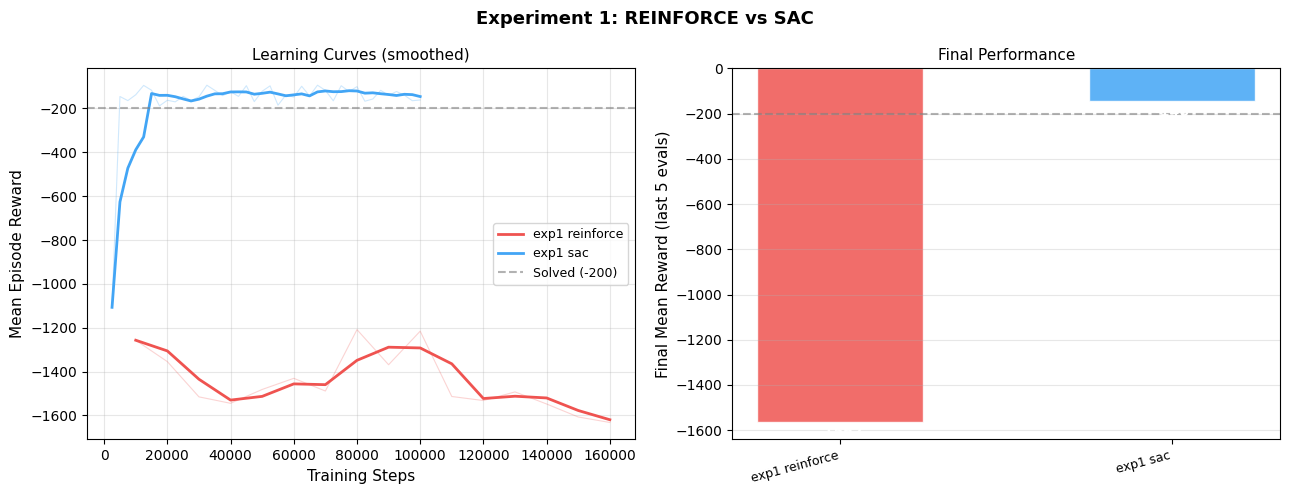

In [9]:
plot_comparison(
    exp1_results,
    title  = "Experiment 1: REINFORCE vs SAC",
    colors = ["#EF5350", "#42A5F5"],
)

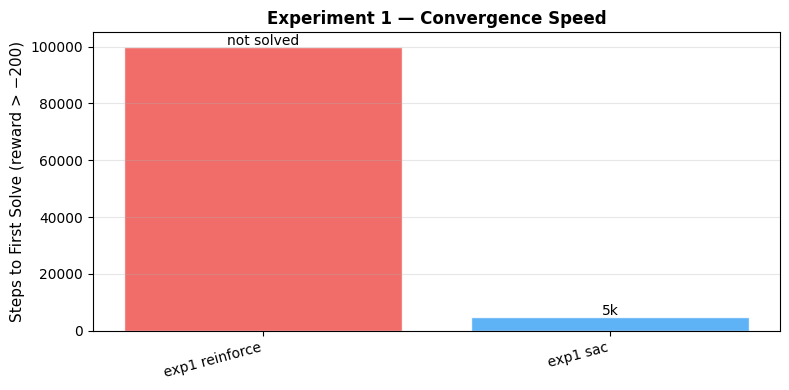

In [10]:
plot_convergence_speed(
    exp1_results,
    title  = "Experiment 1",
    colors = ["#EF5350", "#42A5F5"],
)

In [11]:
df1 = make_table(exp1_results, key_col="n_episodes", key_label="Episodes / Steps")
print("\nExperiment 1 — Results Summary")
print(df1.to_string(index=False))
df1.to_csv(os.path.join(RESULTS_DIR, "exp1_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────


Experiment 1 — Results Summary
    Experiment Algorithm Episodes / Steps Best Reward Final Reward Steps to Solve  Train Time (min)
exp1 reinforce REINFORCE              800     -1208.6      -1562.1     not solved               7.4
      exp1 sac       SAC                —       -94.0       -145.9             5k              61.5


---
## Experiment 2 — Discount Factor γ

**Research question:** How does the discount factor γ affect learning behavior?

γ controls how much the agent values future rewards relative to immediate ones
(AI Lecture Slide 7). A small γ makes the agent short-sighted (only cares about
immediate reward), while γ close to 1 makes it plan far into the future.

For Pendulum, the goal requires sustained control over many timesteps, so a
high γ should be important.

| Variant | γ | Expected behavior |
|---------|---|------------------|
| Low     | 0.90 | Short-sighted, poor sustained control |
| Medium  | 0.95 | Moderate planning horizon |
| High    | 0.99 | Long-term planning — default in literature |

In [12]:
exp2_configs = [
    ("exp2_gamma_090", 0.90),
    ("exp2_gamma_095", 0.95),
    ("exp2_gamma_099", 0.99),
]

exp2_results = []
for name, gamma in exp2_configs:
    res = train_sac(name, gamma=gamma)
    exp2_results.append(res)

print("\nExperiment 2 complete.")


 SAC | exp2_gamma_090
 γ=0.9  batch=256  adaptive_α=True
  Step   2k  reward: -1184.6
  Step   5k  reward: -718.7
  Step   7k  reward: -224.7
  Step  10k  reward: -252.8
  Step  12k  reward: -127.2
  Step  15k  reward: -128.2
  Step  17k  reward: -177.4
  Step  20k  reward: -129.1
  Step  22k  reward: -158.2
  Step  25k  reward: -257.3
  Step  27k  reward: -129.6
  Step  30k  reward: -181.2
  Step  32k  reward: -195.8
  Step  35k  reward: -241.9
  Step  37k  reward: -198.8
  Step  40k  reward: -157.8
  Step  42k  reward: -174.8
  Step  45k  reward: -156.8
  Step  47k  reward: -158.7
  Step  50k  reward: -157.0
  Step  52k  reward: -181.5
  Step  55k  reward: -101.2
  Step  57k  reward: -134.4
  Step  60k  reward: -207.7
  Step  62k  reward: -135.4
  Step  65k  reward: -78.6
  Step  67k  reward: -220.4
  Step  70k  reward: -150.9
  Step  72k  reward: -178.6
  Step  75k  reward: -129.3
  Step  77k  reward: -195.4
  Step  80k  reward: -186.5
  Step  82k  reward: -125.1
  Step  85k  rewar

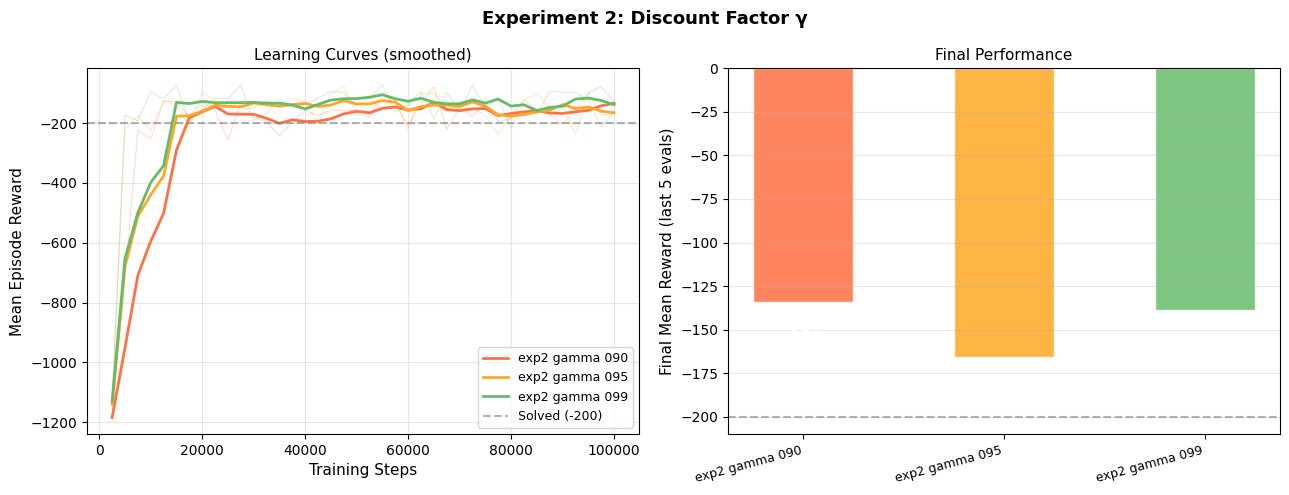

In [13]:
plot_comparison(
    exp2_results,
    title  = "Experiment 2: Discount Factor γ",
    colors = ["#FF7043", "#FFA726", "#66BB6A"],
)

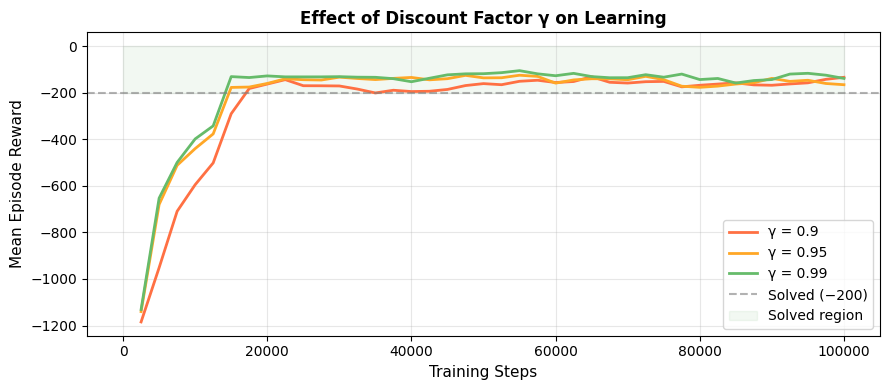

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
gammas  = [0.90, 0.95, 0.99]
colors2 = ["#FF7043", "#FFA726", "#66BB6A"]

for i, res in enumerate(exp2_results):
    rewards = np.array(res["history"]["rewards"])
    steps   = np.array(res["history"]["steps"])
    if len(rewards) == 0:
        continue
    ax.plot(steps, smooth(rewards, 5),
            label=f"γ = {gammas[i]}", color=colors2[i], linewidth=2)

ax.axhline(-200, color="gray", linestyle="--", alpha=0.6, label="Solved (−200)")
ax.fill_between([0, TOTAL_STEPS], [-200, -200], [0, 0],
                alpha=0.05, color="green", label="Solved region")
ax.set_xlabel("Training Steps", fontsize=11)
ax.set_ylabel("Mean Episode Reward", fontsize=11)
ax.set_title("Effect of Discount Factor γ on Learning", fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp2_gamma_effect.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [15]:
df2 = make_table(exp2_results, key_col="gamma", key_label="γ")
print("\nExperiment 2 — Results Summary")
print(df2.to_string(index=False))
df2.to_csv(os.path.join(RESULTS_DIR, "exp2_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────


Experiment 2 — Results Summary
    Experiment Algorithm    γ Best Reward Final Reward Steps to Solve  Train Time (min)
exp2 gamma 090       SAC 0.90       -77.0       -133.9            12k              40.9
exp2 gamma 095       SAC 0.95       -77.1       -165.8             7k              74.0
exp2 gamma 099       SAC 0.99       -72.8       -138.8             5k             754.9


---
## Experiment 3 — Entropy Regularization (Fixed vs Adaptive α)

**Research question:** Does automatic entropy tuning improve performance
compared to a fixed temperature parameter?

SAC uses entropy regularization to encourage exploration (connected to
exploration concepts from AI Lecture Slide 21). The temperature parameter α
controls the trade-off between reward maximization and entropy maximization:

- **Fixed α:** Set manually (α=0.12, from original paper). May be suboptimal
  for a given environment.
- **Adaptive α:** Automatically tuned during training to maintain a target
  entropy level. Haarnoja et al. (2018b) showed this removes the need for
  manual tuning.

**Hypothesis:** Adaptive α will be more robust and achieve better or equal
performance without manual hyperparameter tuning.

In [ ]:
exp3_configs = [
    ("exp3_fixed_alpha_012",  False, 0.12),
    ("exp3_fixed_alpha_050",  False, 0.50),
    ("exp3_adaptive_alpha",   True,  0.12),
]

exp3_results = []
for name, adaptive, alpha_val in exp3_configs:
    res = train_sac(name, adaptive_alpha=adaptive, alpha=alpha_val)
    exp3_results.append(res)

print("\nExperiment 3 complete.")


 SAC | exp3_fixed_alpha_012
 γ=0.99  batch=256  adaptive_α=False
  Step   2k  reward: -705.2
  Step   5k  reward: -216.0
  Step   7k  reward: -228.9
  Step  10k  reward: -191.2
  Step  12k  reward: -217.9
  Step  15k  reward: -143.8
  Step  17k  reward: -192.9
  Step  20k  reward: -96.1
  Step  22k  reward: -94.7
  Step  25k  reward: -166.5
  Step  27k  reward: -143.0
  Step  30k  reward: -99.2
  Step  32k  reward: -190.1
  Step  35k  reward: -87.9
  Step  37k  reward: -94.7
  Step  40k  reward: -96.5
  Step  42k  reward: -143.0
  Step  45k  reward: -173.4
  Step  47k  reward: -143.9
  Step  50k  reward: -142.3
  Step  52k  reward: -163.2
  Step  55k  reward: -120.7
  Step  57k  reward: -189.6
  Step  60k  reward: -143.0
  Step  62k  reward: -157.1
  Step  65k  reward: -139.2
  Step  67k  reward: -96.6
  Step  70k  reward: -170.1
  Step  72k  reward: -73.3
  Step  75k  reward: -114.2
  Step  77k  reward: -163.4
  Step  80k  reward: -98.2
  Step  82k  reward: -121.0
  Step  85k  reward

In [ ]:
plot_comparison(
    exp3_results,
    title  = "Experiment 3: Entropy Regularization",
    colors = ["#AB47BC", "#7E57C2", "#26C6DA"],
)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
labels3 = ["Fixed α=0.12", "Fixed α=0.50", "Adaptive α"]
colors3 = ["#AB47BC", "#7E57C2", "#26C6DA"]

finals3 = [r["metrics"]["final_reward"] for r in exp3_results]
bests3  = [r["metrics"]["best_reward"]  for r in exp3_results]

x = np.arange(len(labels3))
w = 0.35
ax.bar(x - w/2, bests3,  w, label="Best reward",  color=colors3, alpha=0.6, edgecolor="white")
ax.bar(x + w/2, finals3, w, label="Final reward", color=colors3, alpha=0.95, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(labels3)
ax.axhline(-200, color="gray", linestyle="--", alpha=0.6, label="Solved")
ax.set_ylabel("Reward"); ax.set_title("Entropy Regularization — Best vs Final Reward",
                                       fontsize=11, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp3_alpha_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df3 = make_table(exp3_results, key_col="adaptive_alpha", key_label="Adaptive α")
print("\nExperiment 3 — Results Summary")
print(df3.to_string(index=False))
df3.to_csv(os.path.join(RESULTS_DIR, "exp3_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────

---
## Experiment 4 — Batch Size

**Research question:** How does the mini-batch size affect learning speed
and stability?

The batch size determines how many transitions are sampled from the replay
buffer per gradient update. Larger batches give more stable gradient
estimates but require more memory and computation per step.
Connected to Experience Replay concepts from AI Lecture Slide 24.

| Variant | Batch Size | Expected behavior |
|---------|-----------|------------------|
| Small   | 64        | Noisy gradients, fast per-step, may be unstable |
| Medium  | 128       | Balanced |
| Large   | 256       | Stable gradients, default in SAC paper |

In [ ]:
exp4_configs = [
    ("exp4_batch_064", 64),
    ("exp4_batch_128", 128),
    ("exp4_batch_256", 256),
]

exp4_results = []
for name, bs in exp4_configs:
    res = train_sac(name, batch_size=bs)
    exp4_results.append(res)

print("\nExperiment 4 complete.")

In [ ]:
plot_comparison(
    exp4_results,
    title  = "Experiment 4: Batch Size",
    colors = ["#F06292", "#4DB6AC", "#FFB74D"],
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Experiment 4 — Stability Analysis", fontsize=13, fontweight="bold")
colors4 = ["#F06292", "#4DB6AC", "#FFB74D"]

for i, res in enumerate(exp4_results):
    rewards = np.array(res["history"]["rewards"])
    steps   = np.array(res["history"]["steps"])
    if len(rewards) < 4:
        continue
    label = f"batch={exp4_configs[i][1]}"
    roll_std = pd.Series(rewards).rolling(window=6, min_periods=1).std().fillna(0).values
    axes[0].plot(steps, smooth(rewards, 5), label=label,
                 color=colors4[i], linewidth=2)
    axes[1].plot(steps, roll_std, label=label,
                 color=colors4[i], linewidth=2, linestyle="--")

for ax in axes:
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
axes[0].axhline(-200, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("Smoothed Reward"); axes[0].set_xlabel("Steps")
axes[1].set_title("Rolling Std (lower = more stable)"); axes[1].set_xlabel("Steps")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp4_stability.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df4 = make_table(exp4_results, key_col="batch_size", key_label="Batch Size")
print("\nExperiment 4 — Results Summary")
print(df4.to_string(index=False))
df4.to_csv(os.path.join(RESULTS_DIR, "exp4_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────

---
## Overall Summary

In [ ]:
all_results = exp1_results + exp2_results + exp3_results + exp4_results

rows = []
for r in all_results:
    rows.append({
        "Experiment"       : r["exp_name"].replace("_", " "),
        "Algorithm"        : r["algorithm"],
        "Best Reward"      : f"{r['metrics']['best_reward']:.1f}",
        "Final Reward"     : f"{r['metrics']['final_reward']:.1f}",
        "Steps to Solve"   : (f"{r['metrics']['steps_to_solve']//1000}k"
                              if r['metrics']['steps_to_solve'] else "—"),
        "Train Time (min)" : r["metrics"]["training_time_min"],
    })
df_all = pd.DataFrame(rows)
print("=" * 70)
print("COMPLETE RESULTS SUMMARY — Pendulum-v1")
print("=" * 70)
print(df_all.to_string(index=False))
df_all.to_csv(os.path.join(RESULTS_DIR, "all_summary.csv"), index=False)

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
groups  = [exp1_results, exp2_results, exp3_results, exp4_results]
g_names = ["Exp 1\nREINFORCE vs SAC", "Exp 2\nDiscount γ",
           "Exp 3\nEntropy α", "Exp 4\nBatch Size"]
g_colors = ["#42A5F5", "#66BB6A", "#26C6DA", "#FFB74D"]

bests = [max(g, key=lambda r: r["metrics"]["final_reward"])
         for g in groups]

bars = ax.bar(g_names, [b["metrics"]["final_reward"] for b in bests],
              color=g_colors, alpha=0.85, edgecolor="white", width=0.5)
ax.axhline(-200, color="gray", linestyle="--", alpha=0.6, label="Solved (−200)")
ax.set_ylabel("Best Final Reward per Group", fontsize=11)
ax.set_title("Best Result per Experiment Group — Pendulum-v1",
             fontsize=13, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
for bar, b in zip(bars, bests):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 20,
            b["exp_name"].replace("_", "\n"),
            ha="center", va="top", fontsize=8, color="white")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "overall_summary.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("\n📁 Saved to:", os.path.abspath(RESULTS_DIR))
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"   {f}")